# 04: M2/S1 - Supervised Classification (Token Level)

**Cíl:** Natrénovat klasifikátory (LogReg, SVM, XGBoost) na detekci subjektivity (LJMPNIK).

**Scénáře:**
* **S1a - Baseline (Imbalanced):** Trénink na Gold datech (všechny L0).
* **S1b - Gold Balanced:** Trénink na Gold datech s undersamplingem L0 (1:1).
* **S1d - Noisy Train:** Trénink na Silver datech (větší, ale šum), test na Gold.
* **S1e - Hybrid:** Trénink na mixu Gold + Silver.
* **S1c - Bootstrap:** Test stability S1b (na konci notebooku).

## 1. Setup & Imports

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import logging
from pathlib import Path
import os
from itables import show

from sklearn.metrics import classification_report


# Auto-reload modules for development
%load_ext autoreload
%autoreload 2
%matplotlib inline

# Add src to path
current_dir = os.getcwd()
src_dir = os.path.abspath(os.path.join(current_dir, '..', 'src'))
if src_dir not in sys.path:
    sys.path.append(src_dir)

# Vlastní moduly
import config
import data_splitting
import models
import evaluation
import visualization

# Logging setup
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Nastavení vizualizace
visualization.setup_style()

print(f"✅ Setup complete. Data dir: {config.DATA_DIR}")

⚙️ Configuration loaded. Device: cpu


2026-03-14 13:13:34,895 - INFO - Visualization style applied (ggplot + Set2).


✅ Setup complete. Data dir: C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\data


## 2. Data Check (Přehled scénářů)
Než spustíme trénink, podíváme se, kolik máme dat v jednotlivých scénářích.

In [2]:
SCENARIOS_TO_CHECK = ['baseline', 'noisy_train', 'hybrid']

print(f"{'='*80}")
print(f"📊 DATA CHECK REPORT (M2 - Supervised)")
print(f"{'='*80}")

for scenario in SCENARIOS_TO_CHECK:
    print(f"\n🔹 SCÉNÁŘ: {scenario.upper()}")
    try:
        data = data_splitting.get_train_val_test_splits(
            scenario=scenario,
            level='token',
            filter_type='aggressive', # Pro supervised dáváme aggressive filtr (jen podstatná jména atd.)
            random_state=42
        )
        
        # Pomocná funkce pro výpis
        def print_stats(name, y):
            n_l0, n_l1 = np.sum(y == 0), np.sum(y == 1)
            ratio = n_l0 / n_l1 if n_l1 > 0 else 0
            print(f"   {name:<6} | Total: {len(y):<5} | L0 (Neutral): {n_l0:<4} | L1 (Bias): {n_l1:<4} | Ratio: {ratio:.1f}:1")

        print_stats("TRAIN", data['y_train'])
        print_stats("VAL",   data['y_val'])
        print_stats("TEST",  data['y_test'])
        
    except Exception as e:
        print(f"   ❌ Chyba při načítání: {e}")

2026-03-14 13:13:35,492 - INFO - 📊 Preparing scenario: baseline (token level, aggressive filter)


📊 DATA CHECK REPORT (M2 - Supervised)

🔹 SCÉNÁŘ: BASELINE


2026-03-14 13:13:36,877 - INFO - ✅ Loaded 17557 rows from C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\data\processed\gold_tokens.pkl
2026-03-14 13:13:42,090 - INFO - ✅ Loaded 78991 rows from C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\data\processed\silver_tokens.pkl
2026-03-14 13:13:42,149 - INFO - Splitting 520 documents: 104 test, 41 val, 375 train
2026-03-14 13:13:42,160 - INFO - ✅ Document-level split completed:
2026-03-14 13:13:42,162 - INFO -    Train: 376 docs, 2585 samples
2026-03-14 13:13:42,163 - INFO -    Val:   41 docs, 270 samples
2026-03-14 13:13:42,164 - INFO -    Test:  103 docs, 741 samples
2026-03-14 13:13:42,169 - INFO -    ✓ No document leakage detected between splits
2026-03-14 13:13:42,170 - INFO - ✅ Scenario data prepared:
2026-03-14 13:13:42,173 - INFO -    Train: 2585 samples (L0: 900, L1: 1685)
2026-03-14 13:13:42,175 - INFO -    Val:   270 samples (L0: 96, L1: 174)
2026-03-14 13:13:42,178 - INFO -    Test

   TRAIN  | Total: 2585  | L0 (Neutral): 2409 | L1 (Bias): 176  | Ratio: 13.7:1
   VAL    | Total: 270   | L0 (Neutral): 250  | L1 (Bias): 20   | Ratio: 12.5:1
   TEST   | Total: 741   | L0 (Neutral): 695  | L1 (Bias): 46   | Ratio: 15.1:1

🔹 SCÉNÁŘ: NOISY_TRAIN


2026-03-14 13:13:43,348 - INFO - ✅ Loaded 17557 rows from C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\data\processed\gold_tokens.pkl
2026-03-14 13:13:48,575 - INFO - ✅ Loaded 78991 rows from C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\data\processed\silver_tokens.pkl
2026-03-14 13:13:48,766 - INFO - Splitting 1903 documents: 1 test, 285 val, 1617 train
2026-03-14 13:13:48,792 - INFO - ✅ Document-level split completed:
2026-03-14 13:13:48,793 - INFO -    Train: 1617 docs, 15232 samples
2026-03-14 13:13:48,794 - INFO -    Val:   284 docs, 2697 samples
2026-03-14 13:13:48,796 - INFO -    Test:  2 docs, 19 samples
2026-03-14 13:13:48,804 - INFO -    ✓ No document leakage detected between splits
2026-03-14 13:13:48,830 - INFO - ✅ Scenario data prepared:
2026-03-14 13:13:48,832 - INFO -    Train: 15232 samples (L0: 7099, L1: 8133)
2026-03-14 13:13:48,840 - INFO -    Val:   2697 samples (L0: 1244, L1: 1453)
2026-03-14 13:13:48,844 - INFO -

   TRAIN  | Total: 15232 | L0 (Neutral): 14494 | L1 (Bias): 738  | Ratio: 19.6:1
   VAL    | Total: 2697  | L0 (Neutral): 2567 | L1 (Bias): 130  | Ratio: 19.7:1
   TEST   | Total: 3596  | L0 (Neutral): 3354 | L1 (Bias): 242  | Ratio: 13.9:1

🔹 SCÉNÁŘ: HYBRID


2026-03-14 13:13:50,714 - INFO - ✅ Loaded 17557 rows from C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\data\processed\gold_tokens.pkl
2026-03-14 13:13:57,054 - INFO - ✅ Loaded 78991 rows from C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\data\processed\silver_tokens.pkl
2026-03-14 13:13:57,183 - INFO - Splitting 1472 documents: 294 test, 117 val, 1061 train
2026-03-14 13:13:57,213 - INFO - ✅ Document-level split completed:
2026-03-14 13:13:57,215 - INFO -    Train: 1062 docs, 9463 samples
2026-03-14 13:13:57,222 - INFO -    Val:   117 docs, 1067 samples
2026-03-14 13:13:57,224 - INFO -    Test:  293 docs, 2661 samples
2026-03-14 13:13:57,231 - INFO -    ✓ No document leakage detected between splits
2026-03-14 13:13:57,232 - INFO - ✅ Scenario data prepared:
2026-03-14 13:13:57,238 - INFO -    Train: 9463 samples (L0: 900, L1: 8563)
2026-03-14 13:13:57,240 - INFO -    Val:   1067 samples (L0: 96, L1: 971)
2026-03-14 13:13:57,246 - INFO -

   TRAIN  | Total: 9463  | L0 (Neutral): 8670 | L1 (Bias): 793  | Ratio: 10.9:1
   VAL    | Total: 1067  | L0 (Neutral): 977  | L1 (Bias): 90   | Ratio: 10.9:1
   TEST   | Total: 2661  | L0 (Neutral): 2433 | L1 (Bias): 228  | Ratio: 10.7:1


## 3. Experiment Loop (S1a, S1b, S1d, S1e)
Postupně natrénujeme modely pro všechny definované scénáře.

**Modely:**
* **LogReg:** Logistic Regression (Baseline)
* **SVM (Lin):** Linear SVM (Rychlé, dobré pro text)
* **SVM (RBF):** Kernel SVM (Zachytí nelinearity)
* **XGBoost:** Gradient Boosting (Pokud je dostupný)

In [3]:
# Definice cesty pro ukládání výsledků
RESULTS_PATH = config.RESULTS_DIR / "M2_S1_experiment_results_v3.csv"

# Definice experimentů
EXPERIMENTS = [
    {'id': 'S1a', 'name': 'Baseline (Imbalanced)', 'scenario': 'baseline',    'balance_train': False},
    {'id': 'S1b', 'name': 'Baseline (Balanced)',   'scenario': 'baseline',    'balance_train': True},
    {'id': 'S1d', 'name': 'Noisy Train (Silver)',  'scenario': 'noisy_train', 'balance_train': False}, 
    {'id': 'S1e', 'name': 'Hybrid (Gold+Silver)',  'scenario': 'hybrid',      'balance_train': False},      
]

# "Dummy (Majority)": strategy='most_frequent' — absolutní baseline, vždy predikuje majoritní třídu.
# XGBoost je v seznamu přímo; podmíněný append odstraněn (zabraňoval by duplicitám).
MODELS_TO_TEST = ["LogReg", "SVM (RBF)", "XGBoost", "Dummy (Majority)", "SVM (Lin)", "NaiveBayes", "RandForest"]

In [ ]:
%%script false          # Buňka je přeskočena, ať netrénujeme pokaždé. 

from sklearn.dummy import DummyClassifier

results = []
best_f1 = 0.0
best_run = None

print(f"🚀 STARTING EXPERIMENTS ({len(EXPERIMENTS)} scenarios x {len(MODELS_TO_TEST)} models)...")
print(f"💾 Results will be saved continuously to: {RESULTS_PATH}")

for exp in EXPERIMENTS:
    print(f"\n{'='*60}")
    print(f"🧪 SCENARIO: {exp['id']} - {exp['name']}")
    print(f"{'='*60}")
    
    # 1. Načtení dat
    data = data_splitting.get_train_val_test_splits(
        scenario=exp['scenario'], level='token', filter_type='aggressive', random_state=42
    )
    X_train, y_train = data['X_train'], data['y_train']
    X_val, y_val = data['X_val'], data['y_val']
    X_test, y_test = data['X_test'], data['y_test']
    
    # 2. Manuální Undersampling pro S1b
    if exp['balance_train'] and exp['scenario'] == 'baseline':
        idx_l0 = np.where(y_train == 0)[0]
        idx_l1 = np.where(y_train == 1)[0]
        np.random.seed(42)
        idx_l0_down = np.random.choice(idx_l0, size=len(idx_l1), replace=False)
        idx_balanced = np.concatenate([idx_l0_down, idx_l1])
        np.random.shuffle(idx_balanced)
        X_train, y_train = X_train[idx_balanced], y_train[idx_balanced]

    # 3. XGBoost Tuning (per-scenario — different data → different optimal params)
    print(f"   ⚙️ Tuning XGBoost for scenario {exp['id']}...")
    best_xgb_params = models.tune_xgboost(X_train, y_train, config.XGBOOST_PARAM_GRID)
    print(f"   ✅ Best XGBoost params: {best_xgb_params}")

    # 4. Trénink
    for model_name in MODELS_TO_TEST:
        print(f"   ⚙️ Training {model_name}...")
        try:
            # Dummy (Majority): strategy='most_frequent', přímo — bez models.py
            if model_name == "Dummy (Majority)":
                clf = DummyClassifier(strategy='most_frequent', random_state=42)
            elif model_name == "XGBoost":
                clf = models.get_supervised_model(model_name, random_state=42, **best_xgb_params)
            else:
                clf = models.get_supervised_model(model_name, random_state=42)
            
            clf.fit(X_train, y_train)
            
            # --- ZÍSKÁNÍ SKÓRE ---
            if hasattr(clf, "predict_proba"):
                s_train = clf.predict_proba(X_train)[:, 1]
                s_val = clf.predict_proba(X_val)[:, 1]
                s_test = clf.predict_proba(X_test)[:, 1]
            else:
                s_train = clf.decision_function(X_train)
                s_val = clf.decision_function(X_val)
                s_test = clf.decision_function(X_test)
            
            # --- OPTIMALIZACE PRAHU (NA VAL) ---
            threshold, _ = evaluation.find_optimal_threshold(y_val, s_val, metric='f1')
            
            # --- APLIKACE PRAHU ---
            p_train = (s_train > threshold).astype(int)
            p_val = (s_val > threshold).astype(int)
            p_test = (s_test > threshold).astype(int)
            
            # --- VÝPOČET METRIK ---
            m_train = evaluation.calculate_metrics(y_train, p_train, s_train)
            m_val = evaluation.calculate_metrics(y_val, p_val, s_val)
            m_test = evaluation.calculate_metrics(y_test, p_test, s_test)
            
            res = {
                'id': exp['id'],
                'scenario': exp['scenario'],       
                'scenario_name': exp['name'],     
                'model': model_name,
                'threshold': threshold,
                'balance_train': exp['balance_train'],
                
                'train_f1': m_train['f1'], 'train_auprc': m_train['avg_precision'], 
                'train_roc_auc': m_train['roc_auc'], 'train_prec': m_train['precision'], 'train_rec': m_train['recall'],
                
                'val_f1': m_val['f1'], 'val_auprc': m_val['avg_precision'],
                'val_roc_auc': m_val['roc_auc'], 'val_prec': m_val['precision'], 'val_rec': m_val['recall'],
                
                'test_f1': m_test['f1'], 'test_auprc': m_test['avg_precision'],
                'test_roc_auc': m_test['roc_auc'], 'test_prec': m_test['precision'], 'test_rec': m_test['recall'],
            }
            results.append(res)
            pd.DataFrame(results).to_csv(RESULTS_PATH, index=False)

            if m_test['f1'] > best_f1:
                best_f1 = m_test['f1']
                best_run = {'info': res, 'model': clf, 'data': data, 'scores_test': s_test, 'y_test': y_test}
            
            print(f"      Done. F1 [T:{m_train['f1']:.2f} | V:{m_val['f1']:.2f} | Test:{m_test['f1']:.2f}] | AUPRC Test:{m_test['avg_precision']:.3f}")
            
        except Exception as e:
            print(f"      ❌ Error: {e}")

print(f"\n✅ All experiments finished. Saved to {RESULTS_PATH}")

2026-03-14 13:13:57,965 - INFO - 📊 Preparing scenario: baseline (token level, aggressive filter)


🚀 STARTING EXPERIMENTS (4 scenarios x 7 models)...
💾 Results will be saved continuously to: C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\results\M2_S1_experiment_results_v3.csv

🧪 SCENARIO: S1a - Baseline (Imbalanced)


2026-03-14 13:13:59,545 - INFO - ✅ Loaded 17557 rows from C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\data\processed\gold_tokens.pkl
2026-03-14 13:14:05,212 - INFO - ✅ Loaded 78991 rows from C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\data\processed\silver_tokens.pkl
2026-03-14 13:14:05,377 - INFO - Splitting 520 documents: 104 test, 41 val, 375 train
2026-03-14 13:14:05,391 - INFO - ✅ Document-level split completed:
2026-03-14 13:14:05,393 - INFO -    Train: 376 docs, 2585 samples
2026-03-14 13:14:05,396 - INFO -    Val:   41 docs, 270 samples
2026-03-14 13:14:05,409 - INFO -    Test:  103 docs, 741 samples
2026-03-14 13:14:05,417 - INFO -    ✓ No document leakage detected between splits
2026-03-14 13:14:05,423 - INFO - ✅ Scenario data prepared:
2026-03-14 13:14:05,427 - INFO -    Train: 2585 samples (L0: 900, L1: 1685)
2026-03-14 13:14:05,430 - INFO -    Val:   270 samples (L0: 96, L1: 174)
2026-03-14 13:14:05,433 - INFO -    Test

   ⚙️ Tuning XGBoost for scenario S1a...


2026-03-14 13:17:42,920 - INFO - Best XGBoost params (AUPRC=0.6729): {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 1.0}


...

      Done. F1 [T:0.98 | V:0.61 | Test:0.53] | AUPRC Test:0.559

🧪 SCENARIO: S1e - Hybrid (Gold+Silver)


2026-03-14 13:31:53,201 - INFO - ✅ Loaded 17557 rows from C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\data\processed\gold_tokens.pkl
2026-03-14 13:31:55,132 - INFO - ✅ Loaded 78991 rows from C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\data\processed\silver_tokens.pkl
2026-03-14 13:31:55,183 - INFO - Splitting 1472 documents: 294 test, 117 val, 1061 train
2026-03-14 13:31:55,193 - INFO - ✅ Document-level split completed:
2026-03-14 13:31:55,194 - INFO -    Train: 1062 docs, 9463 samples
2026-03-14 13:31:55,194 - INFO -    Val:   117 docs, 1067 samples
2026-03-14 13:31:55,195 - INFO -    Test:  293 docs, 2661 samples
2026-03-14 13:31:55,197 - INFO -    ✓ No document leakage detected between splits
2026-03-14 13:31:55,198 - INFO - ✅ Scenario data prepared:
2026-03-14 13:31:55,200 - INFO -    Train: 9463 samples (L0: 900, L1: 8563)
2026-03-14 13:31:55,201 - INFO -    Val:   1067 samples (L0: 96, L1: 971)
2026-03-14 13:31:55,202 - INFO -

   ⚙️ Tuning XGBoost for scenario S1e...


2026-03-14 13:38:16,869 - INFO - Best XGBoost params (AUPRC=0.7251): {'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


   ✅ Best XGBoost params: {'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
   ⚙️ Training LogReg...
      Done. F1 [T:0.82 | V:0.72 | Test:0.65] | AUPRC Test:0.703
   ⚙️ Training SVM (RBF)...
      Done. F1 [T:0.81 | V:0.75 | Test:0.70] | AUPRC Test:0.733
   ⚙️ Training XGBoost...
      Done. F1 [T:1.00 | V:0.72 | Test:0.67] | AUPRC Test:0.707
   ⚙️ Training Dummy (Majority)...
      Done. F1 [T:0.00 | V:0.00 | Test:0.00] | AUPRC Test:0.086
   ⚙️ Training SVM (Lin)...
      Done. F1 [T:0.87 | V:0.69 | Test:0.61] | AUPRC Test:0.662
   ⚙️ Training NaiveBayes...
      Done. F1 [T:0.59 | V:0.54 | Test:0.55] | AUPRC Test:0.492
   ⚙️ Training RandForest...
      Done. F1 [T:0.98 | V:0.59 | Test:0.60] | AUPRC Test:0.641

✅ All experiments finished. Saved to C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\results\M2_S1_experiment_results_v3.csv


## 4. Results Overview
Srovnání všech modelů a scénářů.

In [5]:
# RESULTS_PATH = config.RESULTS_DIR / "M2_S1_experiment_results_v3.csv"     # možno upravit pro načtení jiného souboru

if RESULTS_PATH.exists():
    df_results = pd.read_csv(RESULTS_PATH)
    print(f"📂 Loaded results from: {RESULTS_PATH}")
    print(f"   Počet záznamů: {len(df_results)}")
else:
    print("⚠️ Výsledkový soubor neexistuje.")
    # Fallback, pokud bys to pustil hned po tréninku bez uložení (což se díky úpravě výše nestane)
    if 'results' in locals() and results:
        df_results = pd.DataFrame(results)

# 2. Pivot Table: Srovnání F1 Skóre
if not df_results.empty:
    pivot_f1 = df_results.pivot_table(
        values='test_f1', 
        index='scenario', 
        columns='model', 
        aggfunc='max'
    )

    print("\n📊 SROVNÁNÍ F1 SKÓRE:")
    display(pivot_f1.style.background_gradient(cmap='Greens', axis=None).format("{:.4f}"))

    # 3. Pivot Table: Srovnání AUPRC
    pivot_auprc = df_results.pivot_table(
        values='test_auprc', 
        index='scenario', 
        columns='model', 
        aggfunc='max'
    )

    print("\n📊 SROVNÁNÍ AUPRC:")
    display(pivot_auprc.style.background_gradient(cmap='Blues', axis=None).format("{:.4f}"))

📂 Loaded results from: C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\results\M2_S1_experiment_results_v3.csv
   Počet záznamů: 28

📊 SROVNÁNÍ F1 SKÓRE:


model,Dummy (Majority),LogReg,NaiveBayes,RandForest,SVM (Lin),SVM (RBF),XGBoost
scenario,,,,,,,
baseline,0.0000,0.6173,0.0000,0.5357,0.6098,0.6667,0.5545
hybrid,0.0000,0.6532,0.5515,0.6038,0.6117,0.6953,0.6722
noisy_train,0.0000,0.5570,0.0000,0.5336,0.5269,0.5962,0.5436



📊 SROVNÁNÍ AUPRC:


model,Dummy (Majority),LogReg,NaiveBayes,RandForest,SVM (Lin),SVM (RBF),XGBoost
scenario,,,,,,,
baseline,0.0621,0.6988,0.4030,0.5969,0.6607,0.7038,0.6341
hybrid,0.0857,0.7033,0.4916,0.6406,0.6618,0.7325,0.7071
noisy_train,0.0673,0.6187,0.4566,0.5588,0.5593,0.6547,0.6015


In [6]:
show(df_results)

Loading ITables v2.6.2 from the internet... (need help?)


📊 Generuji 3-way srovnávací grafy (Pastel Design)...
⚙️ Configuration loaded. Device: cpu
📊 Generuji 3-way srovnávací grafy (podle S1a, S1b...)...
💾 Graf uložen: breakdown_3way_S1a_Baseline_Imbalanced_f1.png


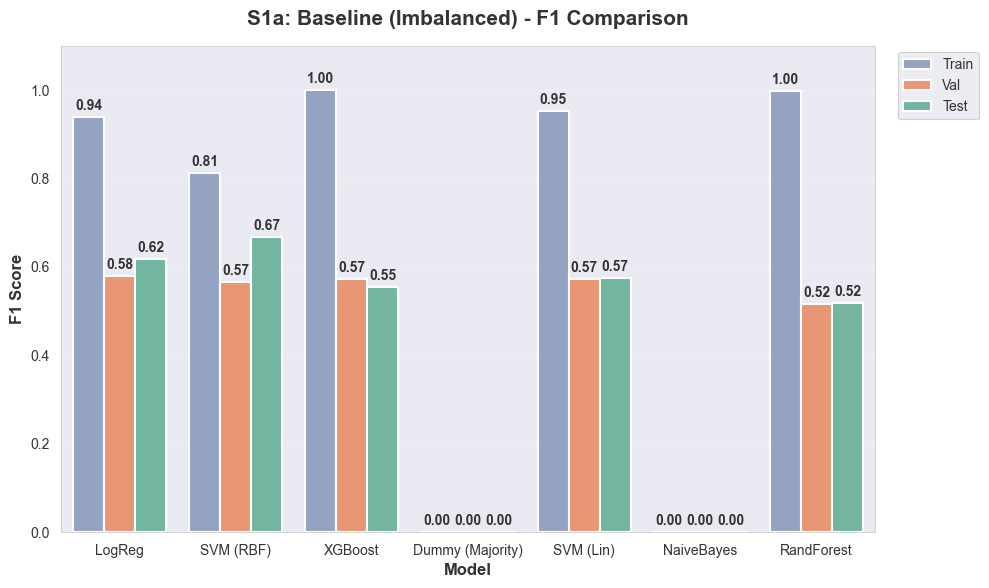

💾 Graf uložen: breakdown_3way_S1b_Baseline_Balanced_f1.png


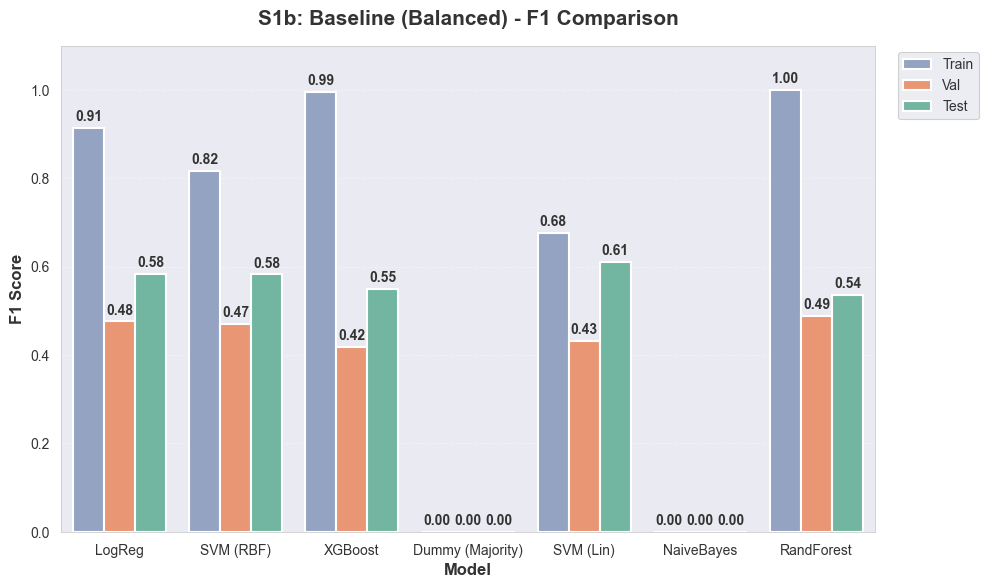

💾 Graf uložen: breakdown_3way_S1d_Noisy_Train_Silver_f1.png


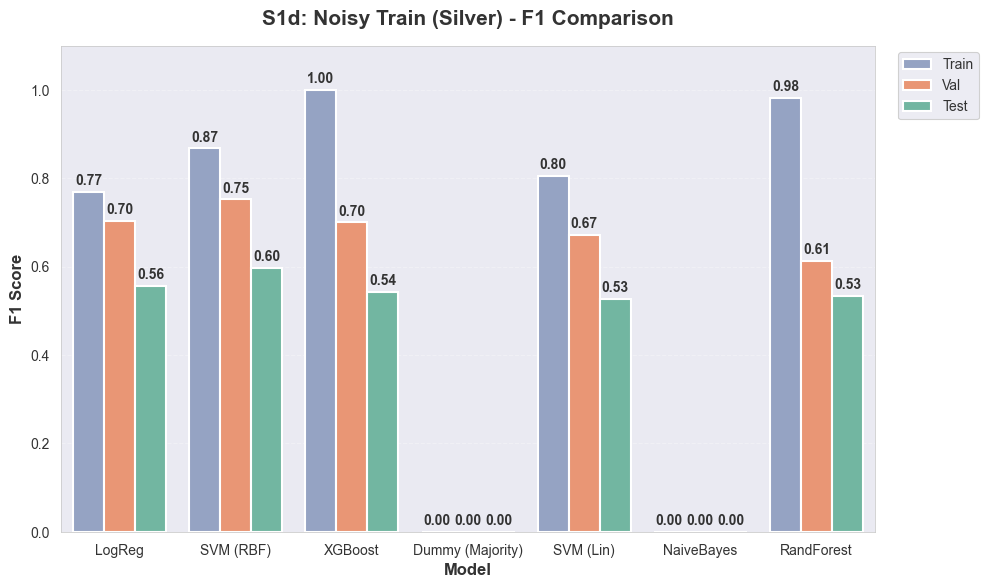

💾 Graf uložen: breakdown_3way_S1e_Hybrid_Gold+Silver_f1.png


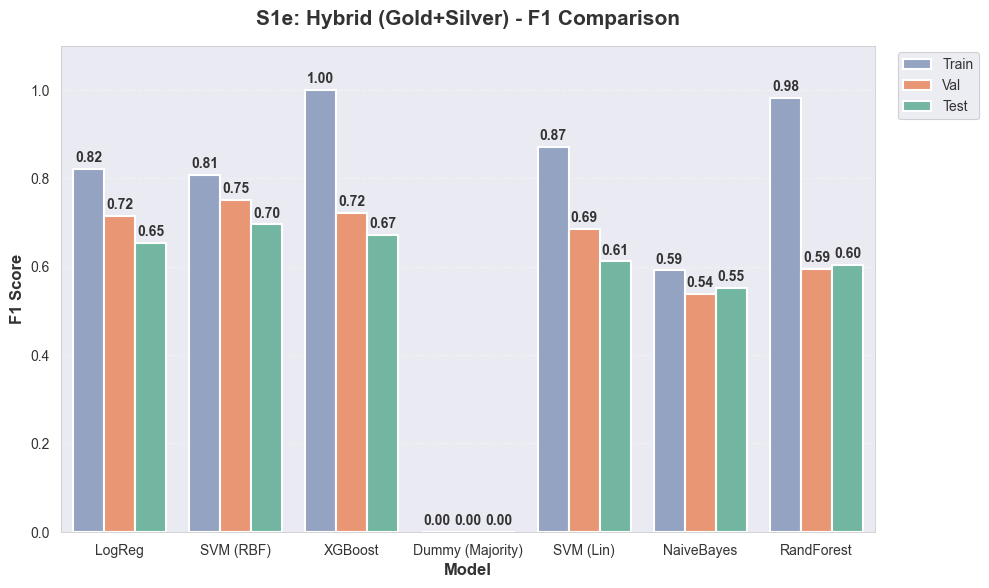

💾 Graf uložen: breakdown_3way_S1a_Baseline_Imbalanced_auprc.png


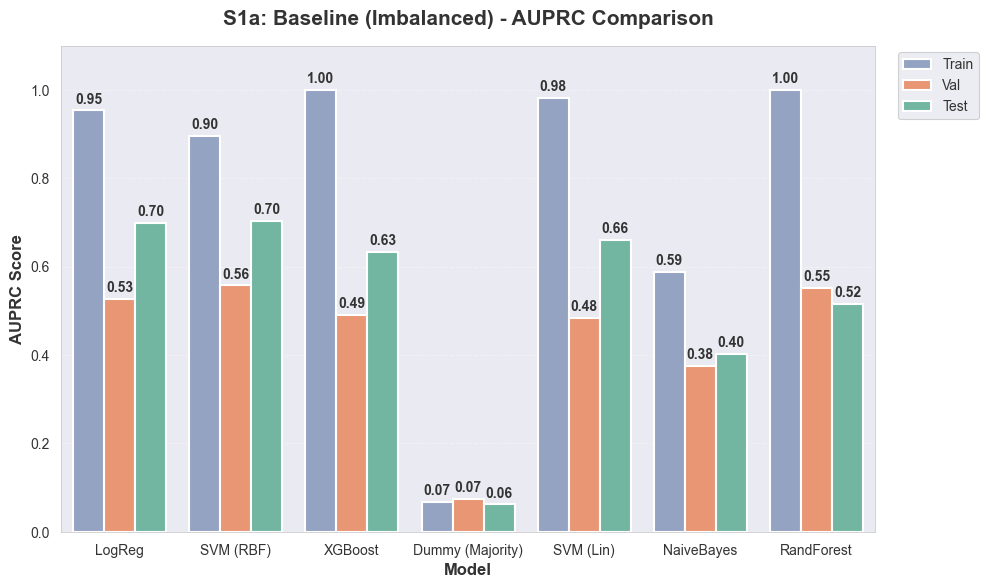

💾 Graf uložen: breakdown_3way_S1b_Baseline_Balanced_auprc.png


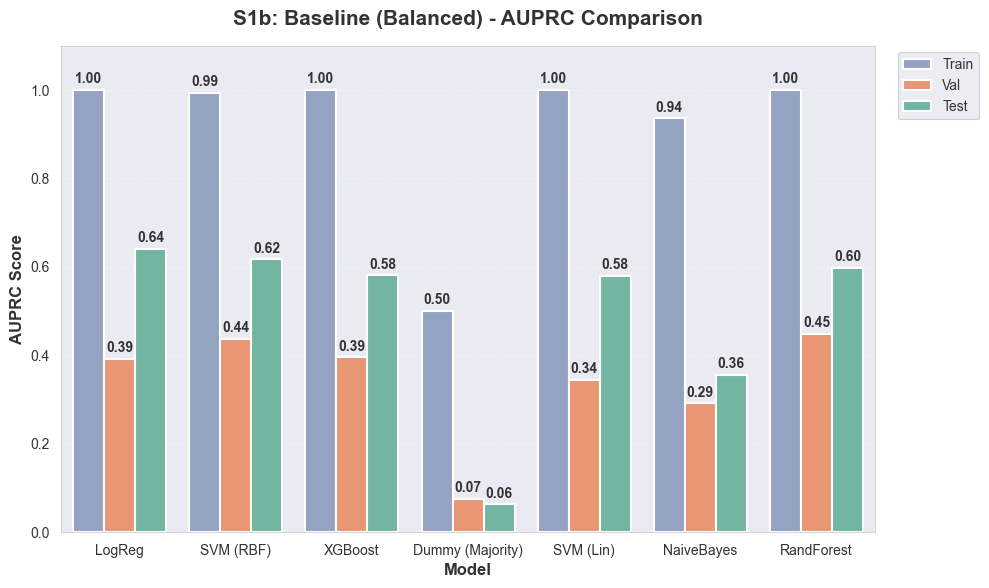

💾 Graf uložen: breakdown_3way_S1d_Noisy_Train_Silver_auprc.png


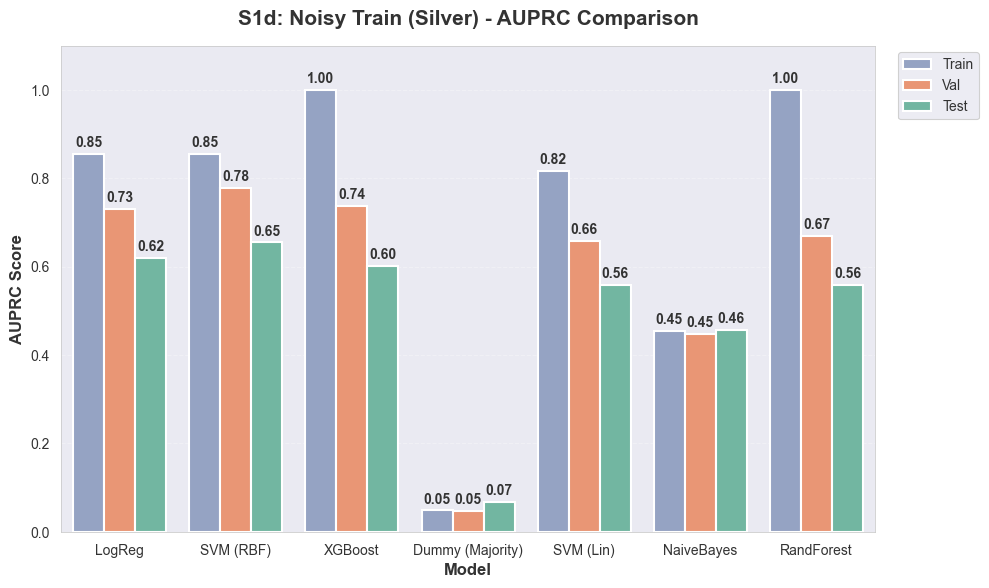

💾 Graf uložen: breakdown_3way_S1e_Hybrid_Gold+Silver_auprc.png


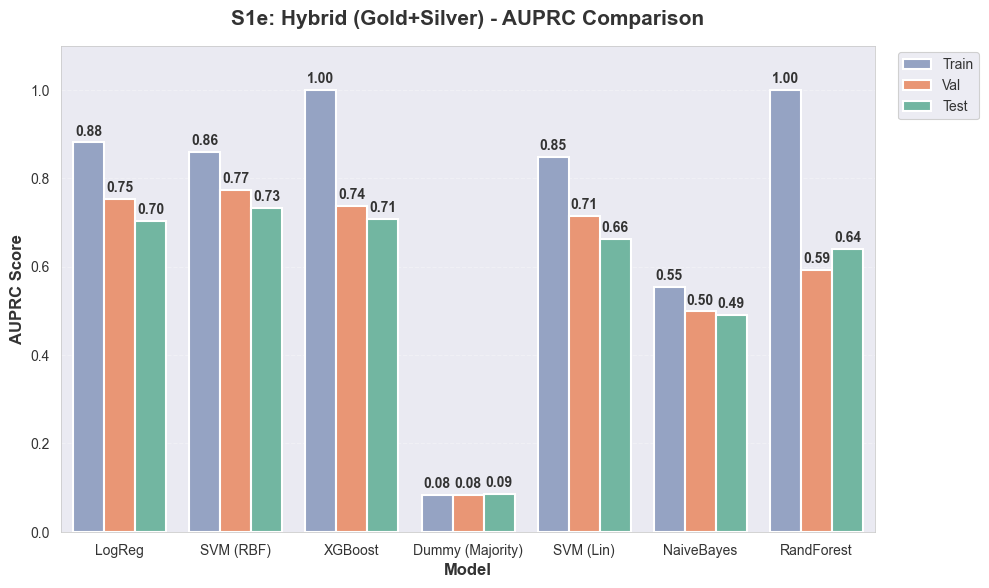

In [7]:
# --- SPUŠTĚNÍ VIZUALIZACE ---
print("📊 Generuji 3-way srovnávací grafy (Pastel Design)...")

# Nezapomeň reloadnout config, pokud jsi ho měnil!
from importlib import reload
reload(config)
reload(visualization)


# --- SPUŠTĚNÍ ---
print("📊 Generuji 3-way srovnávací grafy (podle S1a, S1b...)...")

visualization.plot_three_way_comparison(df_results, metric='f1', save_dir=config.RESULTS_DIR)
visualization.plot_three_way_comparison(df_results, metric='auprc', save_dir=config.RESULTS_DIR)


2026-03-14 13:40:30,524 - INFO - Saved experiment results plot to C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\results\M2_S1_experiment_overview_f1.png


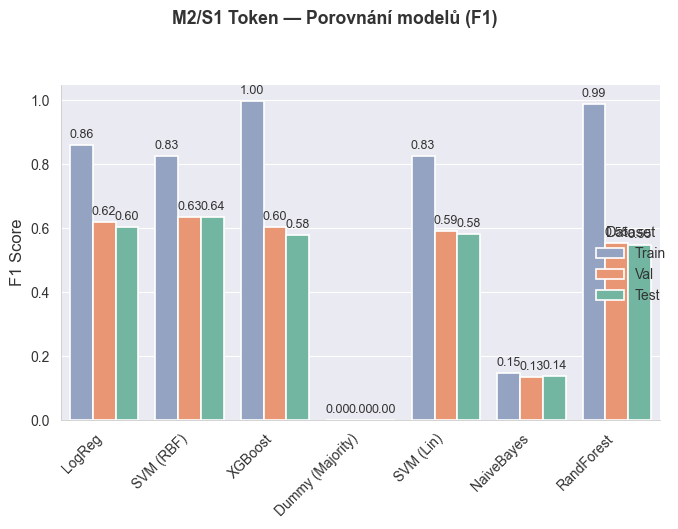

2026-03-14 13:40:30,853 - INFO - Saved experiment results plot to C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\results\M2_S1_experiment_overview_auprc.png


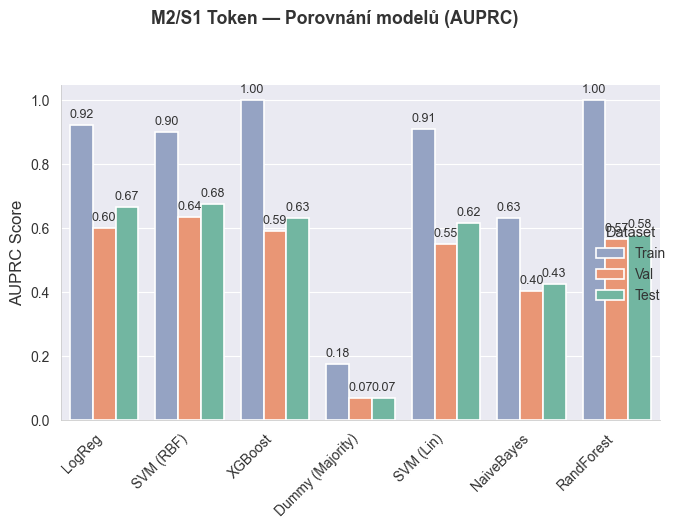

In [8]:
# --- Master Overview: plot_experiment_results ---
# M2/S1 CSV has train_f1/auprc, val_f1/auprc, test_f1/auprc (no pooling col)

visualization.plot_experiment_results(
    df_results, metric='f1', facet_col=None,
    title_prefix="M2/S1 Token — Porovnání modelů",
    save_path=config.RESULTS_DIR / "M2_S1_experiment_overview_f1.png"
)

visualization.plot_experiment_results(
    df_results, metric='auprc', facet_col=None,
    title_prefix="M2/S1 Token — Porovnání modelů",
    save_path=config.RESULTS_DIR / "M2_S1_experiment_overview_auprc.png"
)

## 5. Deep Dive: Best Model Analysis
Detailní pohled na vítěze.

In [9]:
# 5. DEEP DIVE: RETRAIN WINNER & DETAILED ANALYSIS

# 1. Načtení výsledků a nalezení vítěze
if RESULTS_PATH.exists():
    df_results = pd.read_csv(RESULTS_PATH)
    
    # Seřadíme podle F1 na Testu (nebo AUPRC, jak chceš)
    best_row = df_results.sort_values('test_f1', ascending=False).iloc[0]
    
    print(f"🏆 WINNER: {best_row['model']} (ID: {best_row['id']})")
    print(f"🌍 Scenario: {best_row['scenario']}")
    print(f"🎯 Threshold:{best_row['threshold']:.4f}")
    print(f"{'-'*30}")
    print(f"📊 F1 Score: {best_row['test_f1']:.4f}")
    print(f"📈 AUPRC:    {best_row['test_auprc']:.4f}")
    print(f"{'='*60}\n")
    
    # 2. Znovunačtení dat pro vítězný scénář
    print(f"🔄 Reloading data for scenario: {best_row['scenario']}...")
    data_best = data_splitting.get_train_val_test_splits(
        scenario=best_row['scenario'],
        level='token',
        filter_type='aggressive',
        random_state=42
    )
    
    X_train_best, y_train_best = data_best['X_train'], data_best['y_train']
    X_val_best, y_val_best     = data_best['X_val'], data_best['y_val']
    X_test_best, y_test_best   = data_best['X_test'], data_best['y_test']

    # 3. Pokud vyhrál S1b (Manual Balanced), musíme znovu provést undersampling
    if best_row['id'] == 'S1b':
        print("   ⚖️ Re-applying Manual Undersampling (1:1) for S1b...")
        idx_l0 = np.where(y_train_best == 0)[0]
        idx_l1 = np.where(y_train_best == 1)[0]
        
        np.random.seed(42) # Stejný seed zaručí stejná data jako v loopu
        idx_l0_down = np.random.choice(idx_l0, size=len(idx_l1), replace=False)
        idx_balanced = np.concatenate([idx_l0_down, idx_l1])
        np.random.shuffle(idx_balanced)
        
        X_train_best, y_train_best = X_train_best[idx_balanced], y_train_best[idx_balanced]
        print(f"   ✅ New Train Size: {X_train_best.shape[0]}")

    # 4. Retrain Model
    print(f"⚙️ Retraining {best_row['model']}...")
    clf = models.get_supervised_model(best_row['model'], random_state=42)
    clf.fit(X_train_best, y_train_best)
    
    # 5. Získání skóre (Train/Val/Test)
    if hasattr(clf, "predict_proba"):
        s_train = clf.predict_proba(X_train_best)[:, 1]
        s_val   = clf.predict_proba(X_val_best)[:, 1]
        s_test  = clf.predict_proba(X_test_best)[:, 1]
    else:
        s_train = clf.decision_function(X_train_best)
        s_val   = clf.decision_function(X_val_best)
        s_test  = clf.decision_function(X_test_best)

    # 6. Aplikace prahu (Bereme ten uložený z CSV, abychom replikovali výsledek)
    threshold = best_row['threshold']
    
    p_train = (s_train > threshold).astype(int)
    p_val   = (s_val > threshold).astype(int)
    p_test  = (s_test > threshold).astype(int)

    # 7. Final Report
    print(f"\n📢 DETAILED CLASSIFICATION REPORT (Threshold: {threshold:.4f})")
    print(f"{'='*60}")
    
    # Funkce pro hezký výpis metrik
    def print_metrics(name, y_true, y_pred, scores):
        m = evaluation.calculate_metrics(y_true, y_pred, scores)
        print(f"\n🔹 {name} SET Results:")
        print(f"   F1 Score:  {m['f1']:.4f}")
        print(f"   AUPRC:     {m['avg_precision']:.4f}")
        print(f"   ROC AUC:   {m['roc_auc']:.4f}")
        print(f"   Precision: {m['precision']:.4f}")
        print(f"   Recall:    {m['recall']:.4f}")
        print("-" * 40)
        print(classification_report(y_true, y_pred, target_names=['Neutral', 'Anomaly'], digits=4))

    print_metrics("TRAIN", y_train_best, p_train, s_train)
    print_metrics("VAL",   y_val_best,   p_val,   s_val)
    print_metrics("TEST",  y_test_best,  p_test,  s_test)
    
    # 8. Příprava proměnných pro vizualizaci v další buňce
    # Simulujeme strukturu 'best_run', aby fungovaly staré vizualizační funkce
    best_run = {
        'info': best_row.to_dict(),
        'model': clf,
        'data': data_best,
        'scores_test': s_test,
        'y_test': y_test_best,
        'threshold': threshold
    }

else:
    print("⚠️ Nemám výsledky. Spusť nejprve trénovací smyčku.")

2026-03-14 13:40:30,987 - INFO - 📊 Preparing scenario: hybrid (token level, aggressive filter)


🏆 WINNER: SVM (RBF) (ID: S1e)
🌍 Scenario: hybrid
🎯 Threshold:0.2567
------------------------------
📊 F1 Score: 0.6953
📈 AUPRC:    0.7325

🔄 Reloading data for scenario: hybrid...


2026-03-14 13:40:31,276 - INFO - ✅ Loaded 17557 rows from C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\data\processed\gold_tokens.pkl
2026-03-14 13:40:32,907 - INFO - ✅ Loaded 78991 rows from C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\data\processed\silver_tokens.pkl
2026-03-14 13:40:32,967 - INFO - Splitting 1472 documents: 294 test, 117 val, 1061 train
2026-03-14 13:40:32,977 - INFO - ✅ Document-level split completed:
2026-03-14 13:40:32,978 - INFO -    Train: 1062 docs, 9463 samples
2026-03-14 13:40:32,979 - INFO -    Val:   117 docs, 1067 samples
2026-03-14 13:40:32,979 - INFO -    Test:  293 docs, 2661 samples
2026-03-14 13:40:32,981 - INFO -    ✓ No document leakage detected between splits
2026-03-14 13:40:32,981 - INFO - ✅ Scenario data prepared:
2026-03-14 13:40:32,982 - INFO -    Train: 9463 samples (L0: 900, L1: 8563)
2026-03-14 13:40:32,983 - INFO -    Val:   1067 samples (L0: 96, L1: 971)
2026-03-14 13:40:32,984 - INFO -

⚙️ Retraining SVM (RBF)...

📢 DETAILED CLASSIFICATION REPORT (Threshold: 0.2567)

🔹 TRAIN SET Results:
   F1 Score:  0.8072
   AUPRC:     0.8602
   ROC AUC:   0.9896
   Precision: 0.6945
   Recall:    0.9634
----------------------------------------
              precision    recall  f1-score   support

     Neutral     0.9965    0.9612    0.9786      8670
     Anomaly     0.6945    0.9634    0.8072       793

    accuracy                         0.9614      9463
   macro avg     0.8455    0.9623    0.8929      9463
weighted avg     0.9712    0.9614    0.9642      9463


🔹 VAL SET Results:
   F1 Score:  0.7576
   AUPRC:     0.7736
   ROC AUC:   0.9659
   Precision: 0.6944
   Recall:    0.8333
----------------------------------------
              precision    recall  f1-score   support

     Neutral     0.9844    0.9662    0.9752       977
     Anomaly     0.6944    0.8333    0.7576        90

    accuracy                         0.9550      1067
   macro avg     0.8394    0.8998    0.8

### 10-Fold Stratified Cross-Validation (Stability Check)
Ověříme stabilitu vítězného modelu na trénovacích datech pomocí 10-fold stratifikované cross-validace. V každém foldu se trénuje úplně nová instance modelu a měří se AUPRC a F1.

In [10]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, f1_score

# 10-Fold Stratified Cross-Validation on training data
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_auprc = []
cv_f1 = []

print(f"🔄 10-Fold Stratified CV pro {best_row['model']} ({best_row['scenario_name']})")
print(f"   Data: {X_train_best.shape[0]} vzorků, {X_train_best.shape[1]} features")
print(f"   Distribuce: L0={sum(y_train_best==0)}, L1={sum(y_train_best==1)}")
print("-" * 60)

for fold, (train_idx, val_idx) in enumerate(tqdm(skf.split(X_train_best, y_train_best), total=10, desc="CV Folds")):
    X_fold_train, X_fold_val = X_train_best[train_idx], X_train_best[val_idx]
    y_fold_train, y_fold_val = y_train_best[train_idx], y_train_best[val_idx]
    
    # Fresh model instance with same hyperparameters
    clf_cv = models.get_supervised_model(best_row['model'], random_state=42)
    clf_cv.fit(X_fold_train, y_fold_train)
    
    # Predictions
    if hasattr(clf_cv, "predict_proba"):
        y_scores = clf_cv.predict_proba(X_fold_val)[:, 1]
    else:
        y_scores = clf_cv.decision_function(X_fold_val)
    
    # Optimal threshold on this fold's validation
    thresh_cv, _ = evaluation.find_optimal_threshold(y_fold_val, y_scores, metric='f1')
    y_pred_cv = (y_scores > thresh_cv).astype(int)
    
    # Metrics
    auprc = average_precision_score(y_fold_val, y_scores)
    f1 = f1_score(y_fold_val, y_pred_cv)
    
    cv_auprc.append(auprc)
    cv_f1.append(f1)

print(f"\n📊 VÝSLEDKY 10-Fold CV:")
print(f"   AUPRC: {np.mean(cv_auprc):.4f} ± {np.std(cv_auprc):.4f}")
print(f"   F1:    {np.mean(cv_f1):.4f} ± {np.std(cv_f1):.4f}")

🔄 10-Fold Stratified CV pro SVM (RBF) (Hybrid (Gold+Silver))
   Data: 9463 vzorků, 768 features
   Distribuce: L0=8670, L1=793
------------------------------------------------------------


CV Folds:   0%|          | 0/10 [00:00<?, ?it/s]


📊 VÝSLEDKY 10-Fold CV:
   AUPRC: 0.7464 ± 0.0502
   F1:    0.7201 ± 0.0226


2026-03-14 13:50:57,646 - INFO - Saved CV stability plot to C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\results\M2_S1_CV_Stability_SVM_(RBF).png


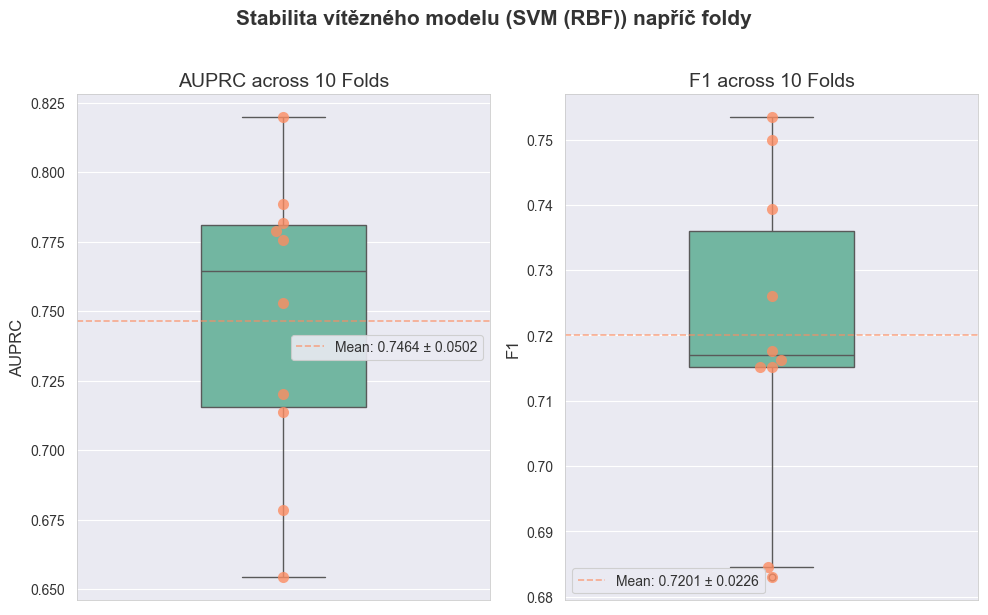

In [11]:
# Vizualizace stability - delegováno na visualization.plot_cv_stability
visualization.plot_cv_stability(
    cv_scores={'AUPRC': cv_auprc, 'F1': cv_f1},
    model_name=best_row['model'],
    save_path=config.RESULTS_DIR / f"M2_S1_CV_Stability_{best_row['model'].replace(' ', '_')}.png"
)

📊 Vizualizace pro model: SVM (RBF) (Hybrid (Gold+Silver))


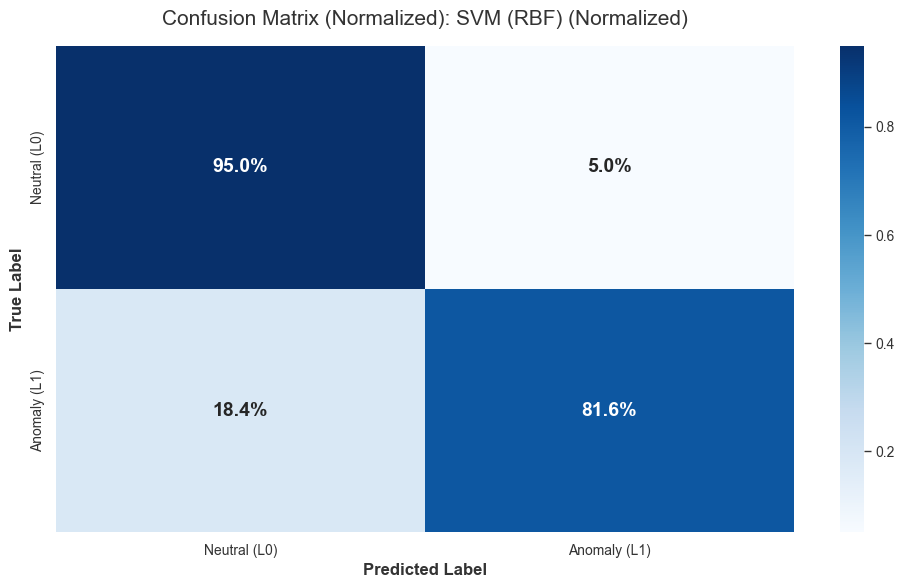

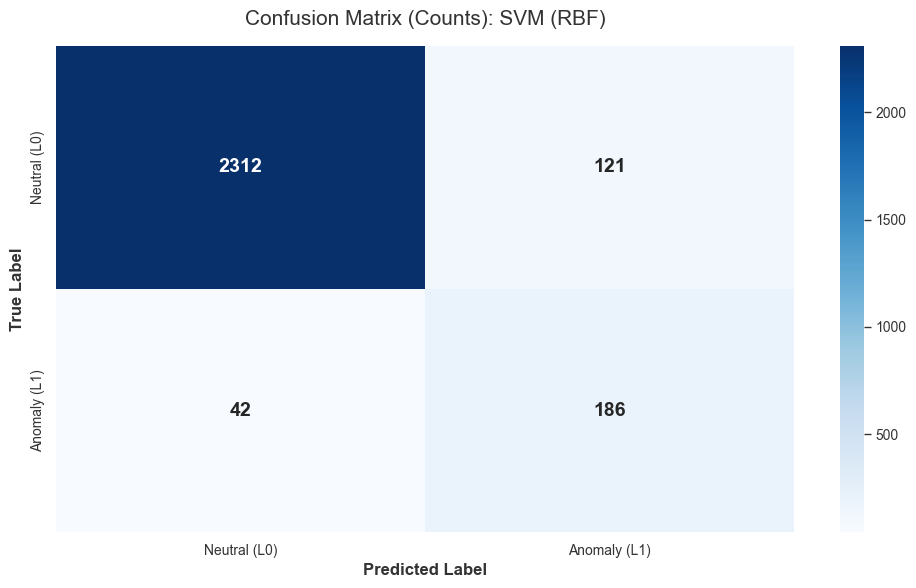

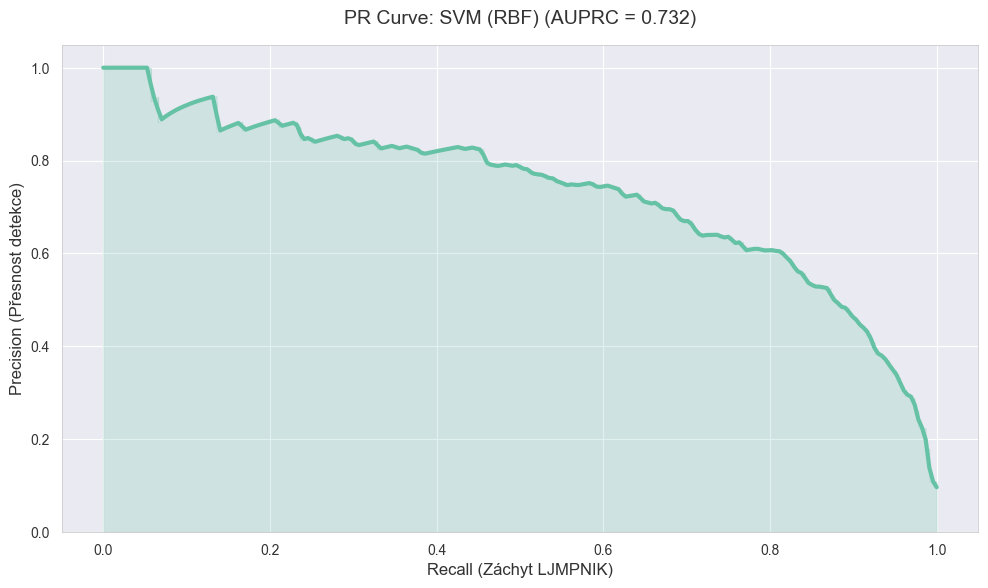

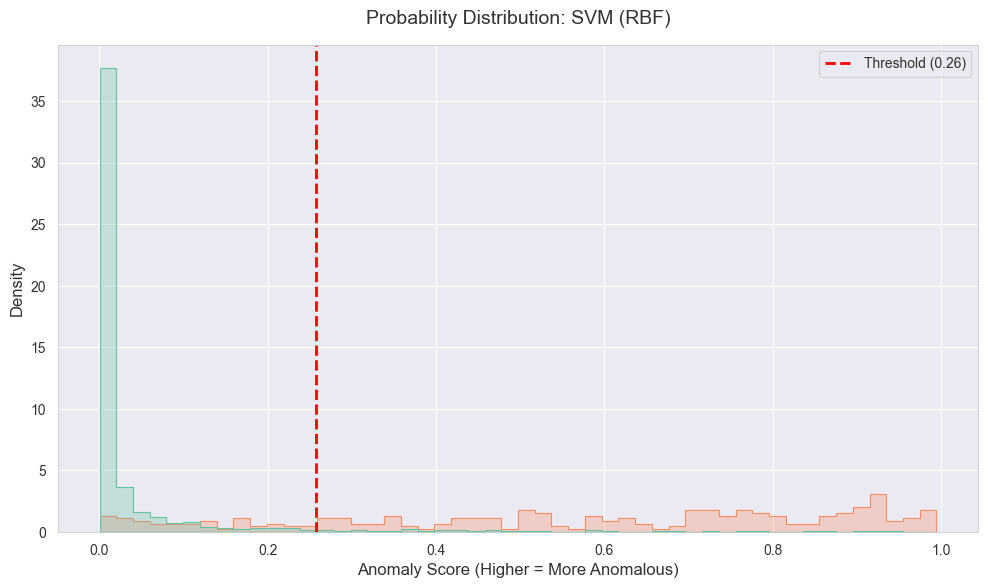

In [12]:
# =============================================================================
# 5b. DEEP DIVE VIZUALIZACE (Confusion Matrix, PR Curve, Hist)
# =============================================================================

# 1. Vytáhneme si metadata z best_run (TOTO CHYBĚLO)
info = best_run['info']

print(f"📊 Vizualizace pro model: {info['model']} ({info.get('scenario_name', info['scenario'])})")

# Přepočítáme y_pred pro jistotu podle prahu
y_pred = (best_run['scores_test'] > info['threshold']).astype(int)

# 2. Confusion Matrix (Normalizovaná - procenta)
visualization.plot_confusion_matrix_heatmap(
    best_run['y_test'], 
    y_pred, 
    normalize=True,
    title=f"Matice záměn (norm.): {info['model']}"
)

# 3. Confusion Matrix (Absolutní počty - pro kontrolu vzorků)
visualization.plot_confusion_matrix_heatmap(
    best_run['y_test'], 
    y_pred, 
    normalize=False,
    title=f"Matice záměn (počty): {info['model']}"
)

# 4. PR Curve
visualization.plot_pr_curve(
    best_run['y_test'], 
    best_run['scores_test'],
    title=f"Křivka PR: {info['model']}"
)

# 5. Histogram Pravděpodobností
visualization.plot_anomaly_histogram(
    best_run['y_test'],
    best_run['scores_test'],
    threshold=info['threshold'],
    title=f"Distribuce pravděpodobností: {info['model']}"
)


⚖️ ANALÝZA KALIBRACE:


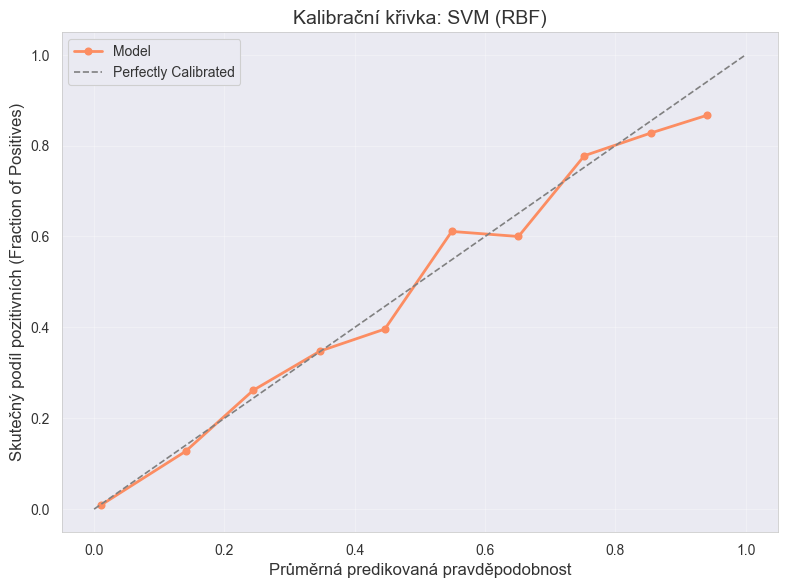

🔍 JAK ČÍST GRAF:
   • Na diagonále = Perfektně kalibrovaný model.
   • Pod diagonálou = Overconfident (Model si věří víc, než by měl).
   • Nad diagonálou = Underconfident (Model je zbytečně opatrný).

ℹ️ Tento model (např. RBF SVM) nemá přímé koeficienty pro interpretaci rysů.


In [13]:
# =============================================================================
# 5c. KALIBRACE A DŮLEŽITOST RYSŮ (Feature Importance)
# =============================================================================

# 1. KALIBRACE MODELU
# Ověříme, jak moc model "kecá" ve svých pravděpodobnostech.
print("\n⚖️ ANALÝZA KALIBRACE:")

# Poznámka: Kalibrace vyžaduje pravděpodobnosti [0, 1]. 
# Pokud model vrací jen decision_function (např. SVM bez probability=True), 
# museli bychom to převést sigmoidou. Ale my máme probability=True.

visualization.plot_model_calibration(
    y_true=best_run['y_test'],
    y_probs=best_run['scores_test'],
    title=f"Kalibrační křivka: {info['model']}",
    save_path=config.RESULTS_DIR / f"calibration_{info['id']}_{info['model']}.png"
)

# Krátká interpretace pro tebe do konzole
print("🔍 JAK ČÍST GRAF:")
print("   • Na diagonále = Perfektně kalibrovaný model.")
print("   • Pod diagonálou = Overconfident (Model si věří víc, než by měl).")
print("   • Nad diagonálou = Underconfident (Model je zbytečně opatrný).")

# -----------------------------------------------------------------------------
# 2. FEATURE IMPORTANCE (Co model považuje za bias?)
# -----------------------------------------------------------------------------
# Toto funguje jen pro lineární modely (LogReg, Linear SVM)
model = best_run['model']

if hasattr(model, 'coef_'):
    print(f"\n🔑 FEATURE IMPORTANCE (Top slova pro {info['model']}):")
    
    # Získání koeficientů
    feature_names = np.array(model.feature_names_in_) if hasattr(model, 'feature_names_in_') else None
    
    # Pokud feature names nemáme v modelu, zkusíme je načíst, pokud víme odkud (BERT dimenze nemají jména)
    # Ale pozor! My trénujeme na EMBEDDINGS (768 čísel). 
    # Tady nám feature importance ukáže jen "Dimenze 123 je důležitá", což nám nic neřekne o slovech.
    
    print("⚠️ Pozor: Trénujeme na BERT Embeddings (768 dimenzí).")
    print("   Koeficienty nám řeknou, která dimenze vektoru je důležitá,")
    print("   ale neřeknou nám přímo konkrétní slova (protože je to dense vector).")
    print("   -> Pro interpretaci slov se musíme dívat na Qualitative Analysis (tabulka výše).")
    
else:
    print("\nℹ️ Tento model (např. RBF SVM) nemá přímé koeficienty pro interpretaci rysů.")

#### Embedding Projection

🎨 Počítám projekce pro SVM (RBF) (Hybrid (Gold+Silver))...


2026-03-14 13:51:03,769 - INFO - 1️⃣ Computing PCA...
2026-03-14 13:51:03,799 - INFO - 2️⃣ Computing t-SNE...
2026-03-14 13:51:11,953 - INFO - 3️⃣ Computing UMAP...



🔹 Vizualizace: PCA


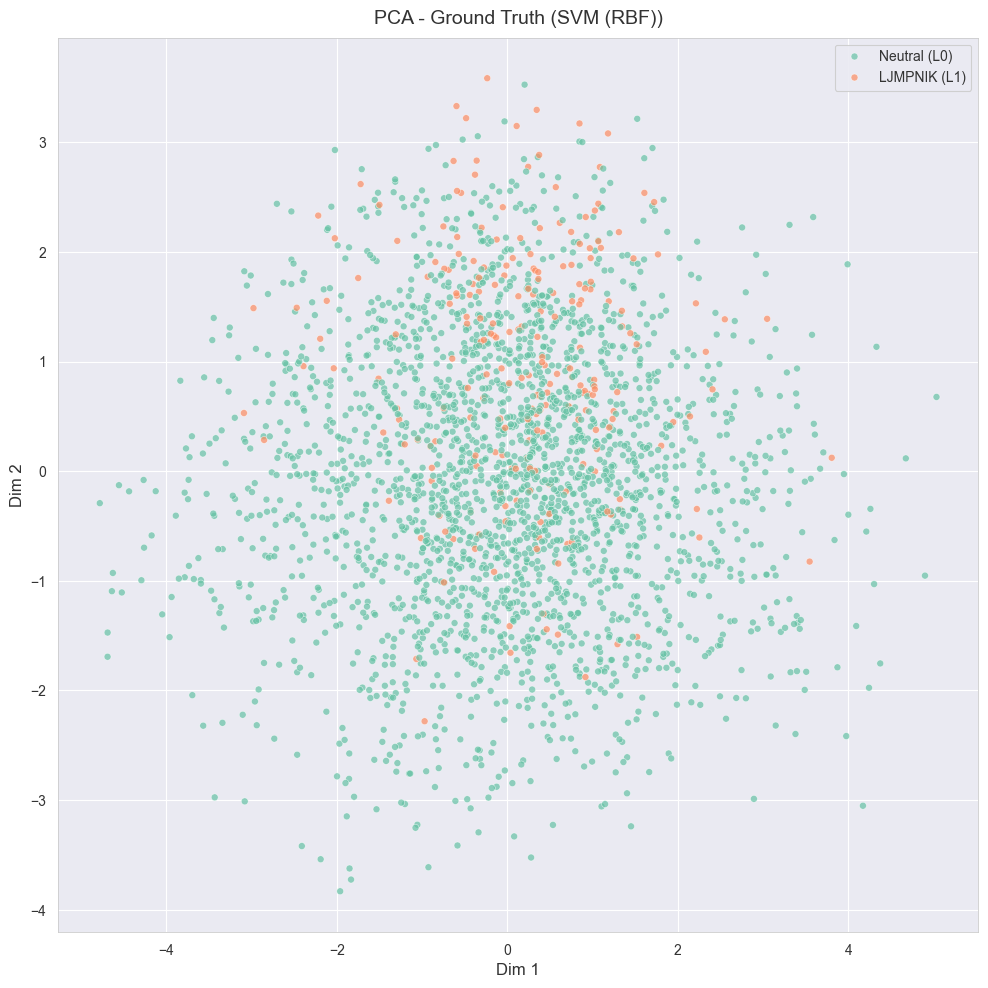

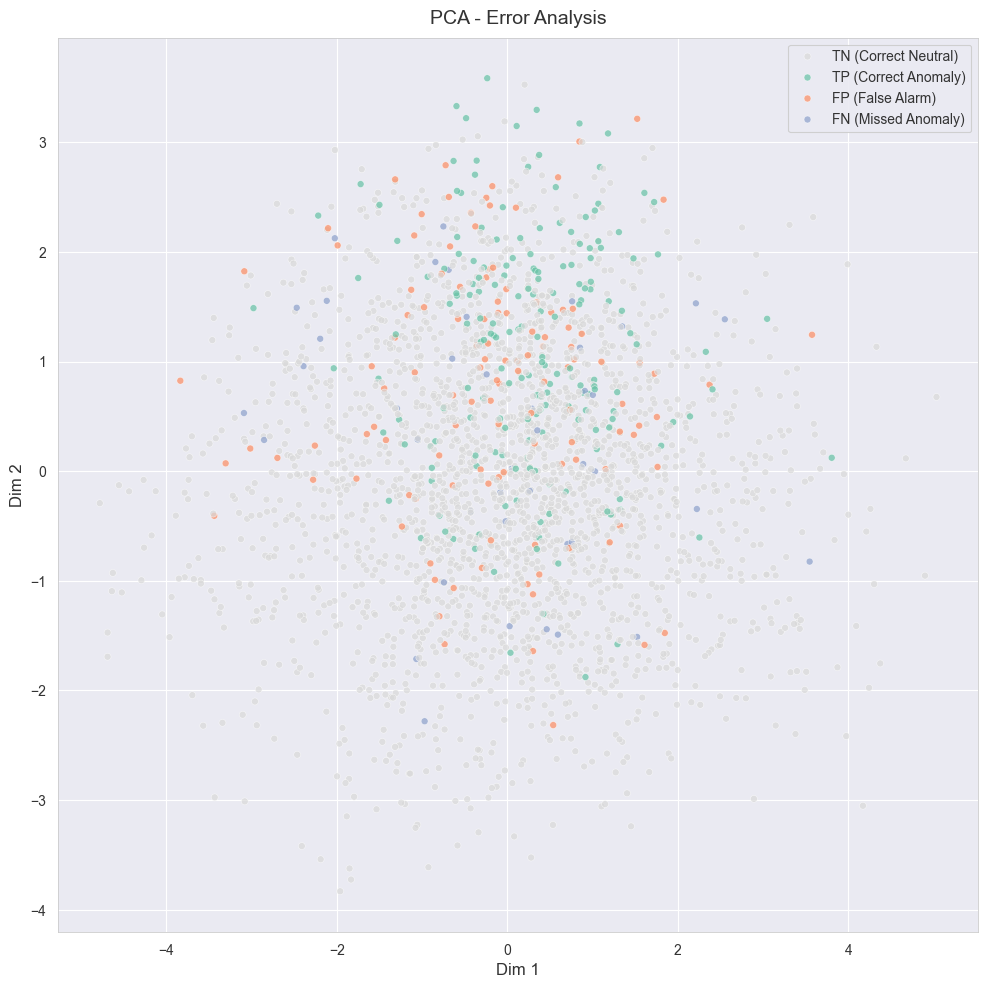


🔹 Vizualizace: t-SNE


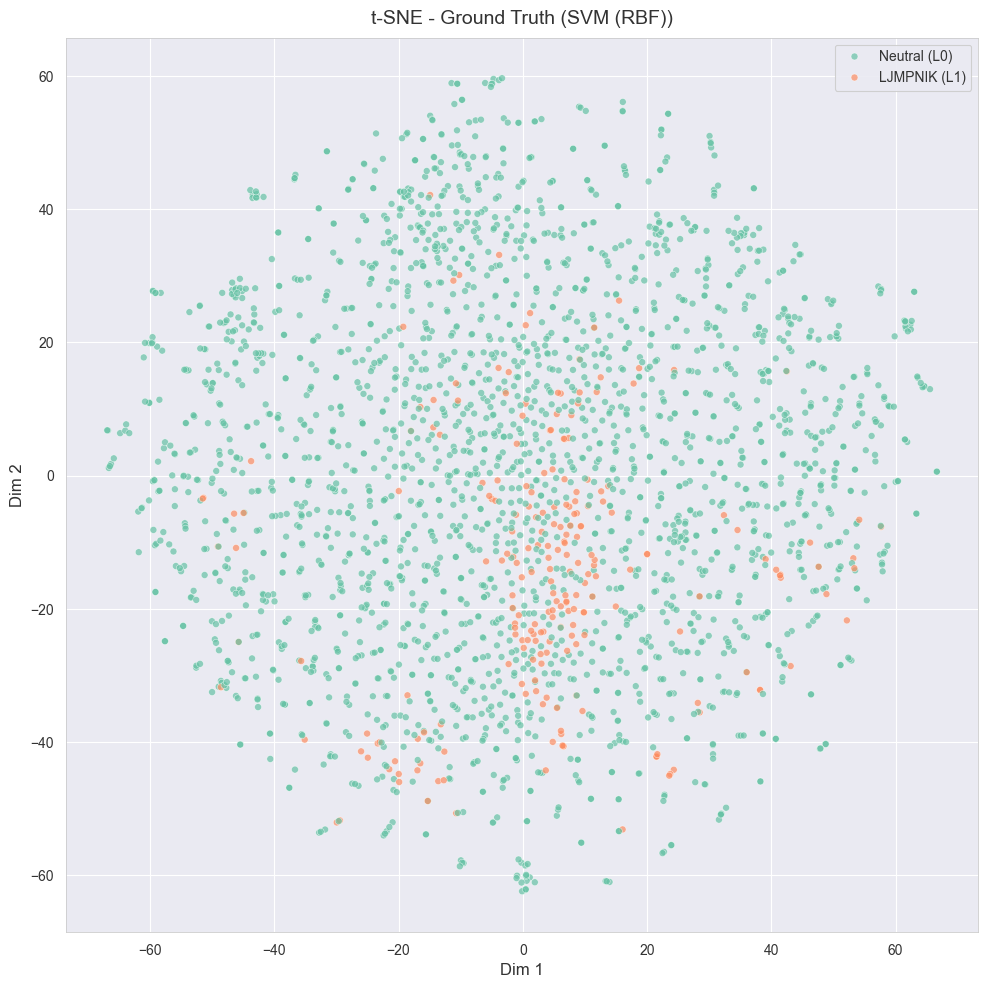

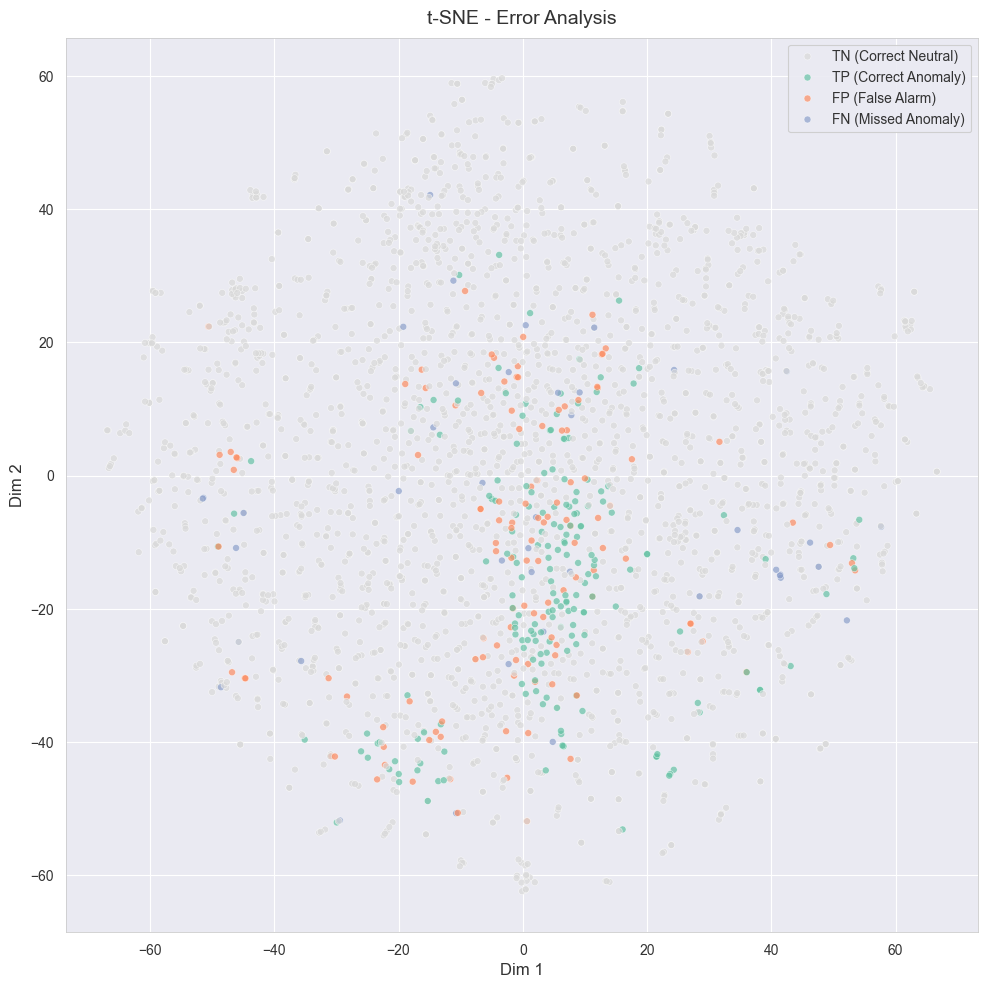


🔹 Vizualizace: UMAP


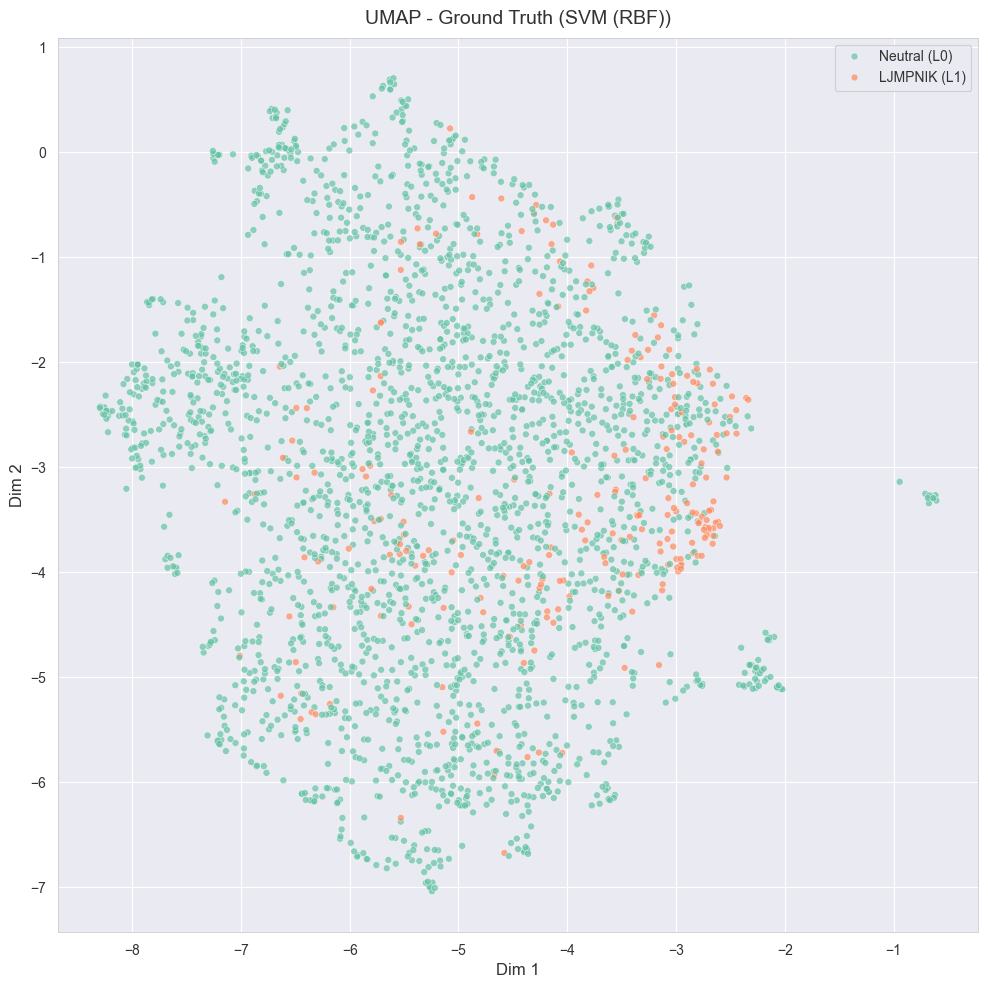

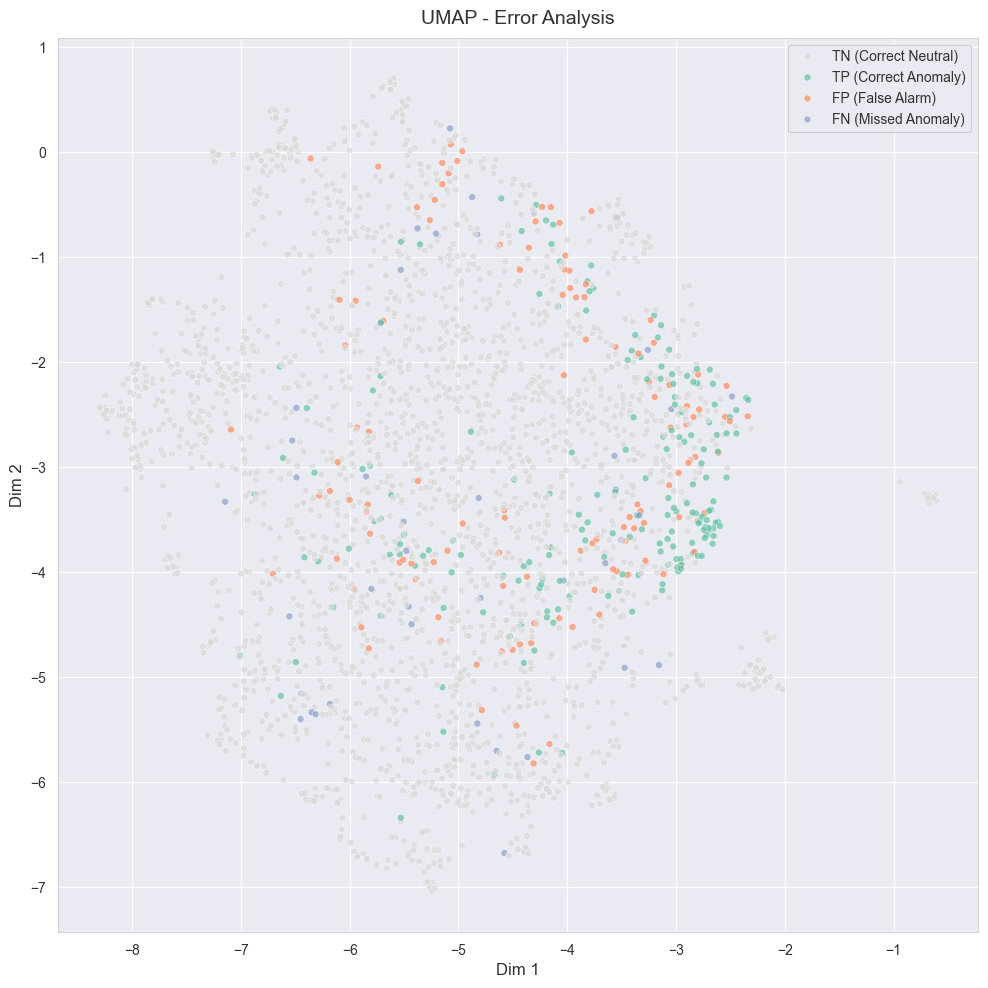


✅ Všechny projekce uloženy.


In [14]:
# PROJEKCE EMBEDDINGŮ (PCA, t-SNE, UMAP)

# Získání názvu modelu a dat z best_run
info = best_run['info']
model_name = info['model']
scenario_name = info.get('scenario_name', info['scenario'])

print(f"🎨 Počítám projekce pro {model_name} ({scenario_name})...")

# 1. Příprava dat
# Bereme X_test přímo z uloženého best_run
X_input = best_run['data']['X_test']
y_test_input = best_run['y_test']
scores_input = best_run['scores_test']

# Dopočítáme y_pred podle prahu (pro Error Analysis)
y_pred_input = (scores_input > info['threshold']).astype(int)

# 2. Výpočet projekcí (funkce sama udělá subsampling, pokud je dat moc)
projections, indices = visualization.compute_projections(
    X_input, 
    methods=['PCA', 't-SNE', 'UMAP'],
    random_state=42
)

# 3. Filtrace labelů (musíme vybrat stejné vzorky, jako vybral subsampling)
y_test_viz = y_test_input[indices]
y_pred_viz = y_pred_input[indices]

# 4. Generování grafů
for method, coords in projections.items():
    print(f"\n🔹 Vizualizace: {method}")
    
    # --- A) Ground Truth (Co to reálně je) ---
    labels_gt = pd.Series(y_test_viz).map({
        0: 'Neutrální (L0)', 
        1: 'Bias/LJMPNIK (L1)'
    })
    
    visualization.plot_embedding_projection(
        coords=coords, 
        labels=labels_gt,
        palette={
            'Neutrální (L0)': config.COLORS['l0'], 
            'Bias/LJMPNIK (L1)': config.COLORS['l1']
        },
        title=f"{method} - Skutečné třídy ({model_name})",
        hue_order=['Neutrální (L0)', 'Bias/LJMPNIK (L1)'],
        save_path=config.RESULTS_DIR / f"M2_proj_{method}_GT_{info['id']}_{model_name}.png"
    )
    
    # --- B) Error Analysis (Kde model chyboval - TP/FP/TN/FN) ---
    visualization.plot_error_analysis_projection(
        coords=coords,
        y_true=y_test_viz,
        y_pred=y_pred_viz,
        method_name=method,
        save_path=config.RESULTS_DIR / f"M2_proj_{method}_Errors_{info['id']}_{model_name}.png"
    )

print("\n✅ Všechny projekce uloženy.")

## 6. Qualitative Analysis (Error Analysis)

In [15]:
if best_run:
    # Metadala z vítězného běhu
    meta_test = best_run['data']['meta_test']
    
    # Dataframe
    df_meta = pd.DataFrame(meta_test)
    
    # Řešení jména sloupce textu (form/text)
    text_col = 'form' if 'form' in df_meta.columns else 'text'
    if text_col not in df_meta.columns:
         text_col = [c for c in df_meta.columns if df_meta[c].dtype == 'object'][0]
    
    # Řešení kontextu (pokud chybí)
    sentences = df_meta['sentence'] if 'sentence' in df_meta.columns else ["[N/A]"] * len(df_meta)

    df_qual = pd.DataFrame({
        'text': df_meta[text_col],
        'sentence': sentences,
        'document_id': df_meta['document_id'],
        'true_label': best_run['y_test'],
        'pred_label': y_pred,
        'prob_score': best_run['scores_test']
    })

    # Kategorie chyby
    conditions = [
        (df_qual.true_label == 1) & (df_qual.pred_label == 1), # TP
        (df_qual.true_label == 0) & (df_qual.pred_label == 0), # TN
        (df_qual.true_label == 0) & (df_qual.pred_label == 1), # FP
        (df_qual.true_label == 1) & (df_qual.pred_label == 0)  # FN
    ]
    df_qual['category'] = np.select(conditions, ['TP', 'TN', 'FP', 'FN'], default='Unknown')

    # Save
    save_path = config.RESULTS_DIR / f"M2_S1_Qual_Analysis_{info['model']}_{info['scenario']}.csv"
    df_qual.to_csv(save_path, index=False)
    print(f"📝 Saved to {save_path}")
    
    print("\n❌ TOP 5 FALSE POSITIVES (Falešný poplach):")
    display(df_qual[df_qual['category'] == 'FP'].sort_values('prob_score', ascending=False).head(5))
    
    print("\n❌ TOP 5 FALSE NEGATIVES (Minuté anomálie):")
    display(df_qual[df_qual['category'] == 'FN'].sort_values('prob_score', ascending=True).head(5))

📝 Saved to C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\results\M2_S1_Qual_Analysis_SVM (RBF)_hybrid.csv

❌ TOP 5 FALSE POSITIVES (Falešný poplach):


,text,sentence,document_id,true_label,pred_label,prob_score,category
7984,erozí,[N/A],silver_doc_0884,0,1,0.952423,FP
2653,průšvih,[N/A],gold_doc_0312,0,1,0.946058,FP
12785,podkopat,[N/A],silver_doc_1823,0,1,0.916010,FP
10034,bestie,[N/A],silver_doc_1284,0,1,0.915778,FP
3797,trollích,[N/A],silver_doc_0040,0,1,0.915139,FP



❌ TOP 5 FALSE NEGATIVES (Minuté anomálie):


,text,sentence,document_id,true_label,pred_label,prob_score,category
4099,dopustili,[N/A],silver_doc_0102,1,0,0.000989,FN
4588,kurátora,[N/A],silver_doc_0204,1,0,0.001070,FN
1958,valorizace,[N/A],gold_doc_0100,1,0,0.006697,FN
9367,snu,[N/A],silver_doc_1150,1,0,0.012020,FN
6219,legendárního,[N/A],silver_doc_0534,1,0,0.012513,FN


## 7. S1c: Bootstrap Validation (Stability Check)
Ověříme stabilitu modelu **Baseline (Balanced)** pomocí 100 náhodných undersamplingů.

2026-03-14 16:54:32,821 - INFO - 📊 Preparing scenario: baseline (token level, aggressive filter)


🔄 SPOUŠTÍM S1c BOOTSTRAPING (100 iterací)
   Modely: ['LogReg', 'SVM (RBF)']
------------------------------------------------------------


2026-03-14 16:54:33,138 - INFO - ✅ Loaded 17557 rows from C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\data\processed\gold_tokens.pkl
2026-03-14 16:54:35,141 - INFO - ✅ Loaded 78991 rows from C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\data\processed\silver_tokens.pkl
2026-03-14 16:54:35,174 - INFO - Splitting 520 documents: 104 test, 41 val, 375 train
2026-03-14 16:54:35,178 - INFO - ✅ Document-level split completed:
2026-03-14 16:54:35,179 - INFO -    Train: 376 docs, 2585 samples
2026-03-14 16:54:35,181 - INFO -    Val:   41 docs, 270 samples
2026-03-14 16:54:35,181 - INFO -    Test:  103 docs, 741 samples
2026-03-14 16:54:35,189 - INFO -    ✓ No document leakage detected between splits
2026-03-14 16:54:35,191 - INFO - ✅ Scenario data prepared:
2026-03-14 16:54:35,192 - INFO -    Train: 2585 samples (L0: 900, L1: 1685)
2026-03-14 16:54:35,192 - INFO -    Val:   270 samples (L0: 96, L1: 174)
2026-03-14 16:54:35,194 - INFO -    Test

Bootstrapping:   0%|          | 0/100 [00:00<?, ?it/s]

✅ Hotovo za 15.3 sekund.


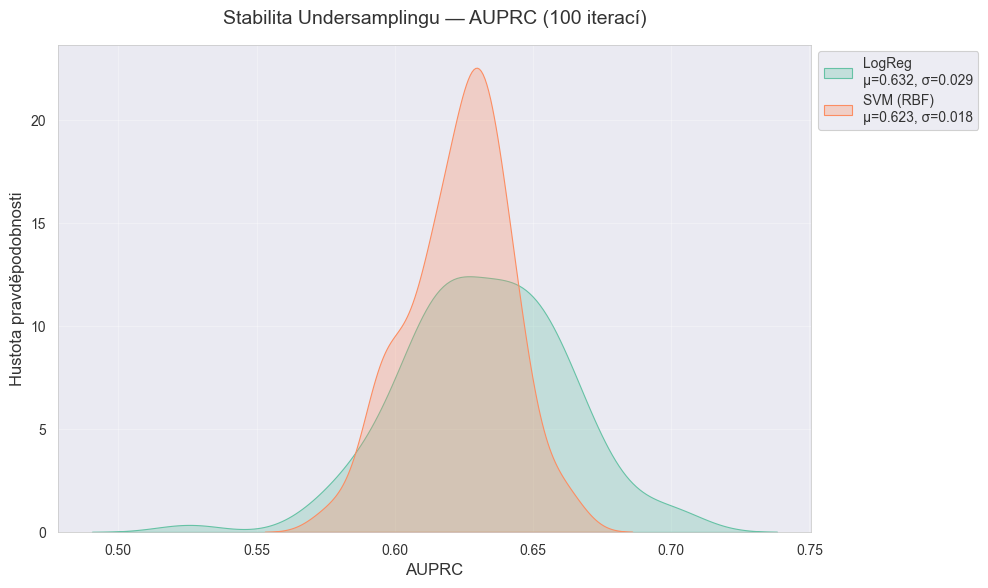


📊 STATISTICKÉ VÝSLEDKY:
🔹 LogReg: Mean=0.6320 | Std=0.0293 | 95% CI: [0.5772, 0.6889]
🔹 SVM (RBF): Mean=0.6233 | Std=0.0180 | 95% CI: [0.5891, 0.6567]


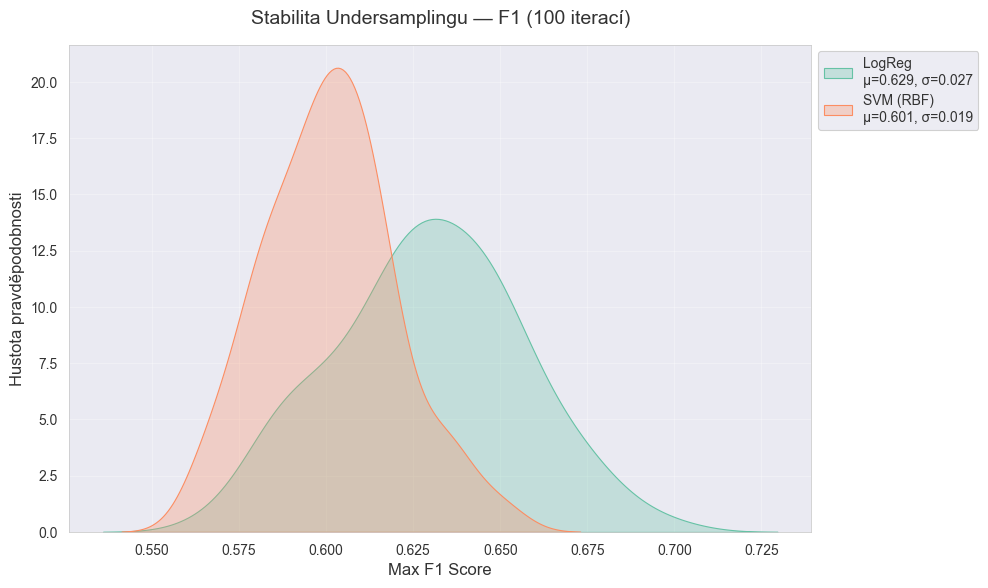


📊 STATISTICKÉ VÝSLEDKY:
🔹 LogReg: Mean=0.6293 | Std=0.0266 | 95% CI: [0.5837, 0.6793]
🔹 SVM (RBF): Mean=0.6010 | Std=0.0186 | 95% CI: [0.5669, 0.6383]


In [17]:
from collections import defaultdict
from sklearn.metrics import average_precision_score
import time

# =============================================================================
# 7. S1c: BOOTSTRAP VALIDATION (STABILITY CHECK)
# =============================================================================
# Ověříme stabilitu modelu Baseline (Balanced) pomocí 100 náhodných undersamplingů.
# Primární metrika: AUPRC (threshold-independent), sekundární: Max F1.

# Konfigurace
N_BOOTSTRAPS = 100            # Pro rychlý test dej 10, pro finále 100
MODELS_TO_TEST = ["LogReg", "SVM (RBF)"] # Kandidáti
SCENARIO = 'baseline'         # Základní data

print(f"🔄 SPOUŠTÍM S1c BOOTSTRAPING ({N_BOOTSTRAPS} iterací)")
print(f"   Modely: {MODELS_TO_TEST}")
print("-" * 60)

bootstrap_auprc = defaultdict(list)
bootstrap_f1 = defaultdict(list)
start_global = time.time()

# 1. Načteme plná data (imbalanced) jen jednou
data_full = data_splitting.get_train_val_test_splits(
    scenario=SCENARIO, level='token', filter_type='aggressive', random_state=config.RANDOM_SEED
)
X_train_full, y_train_full = data_full['X_train'], data_full['y_train']
X_test_fixed, y_test_fixed = data_full['X_test'], data_full['y_test']

# Indexy pro undersampling
idx_l0 = np.where(y_train_full == 0)[0]
idx_l1 = np.where(y_train_full == 1)[0]
n_samples = len(idx_l1) # Chceme poměr 1:1

for i in tqdm(range(N_BOOTSTRAPS), desc="Bootstrapping"):
    
    # 2. Náhodný Undersampling (s měnícím se seedem 'i')
    np.random.seed(i)
    idx_l0_down = np.random.choice(idx_l0, size=n_samples, replace=False)
    idx_balanced = np.concatenate([idx_l0_down, idx_l1])
    np.random.shuffle(idx_balanced)
    
    # Nová trénovací sada pro tuto iteraci
    X_train_iter = X_train_full[idx_balanced]
    y_train_iter = y_train_full[idx_balanced]
    
    for model_name in MODELS_TO_TEST:
        try:
            # 3. Inicializace a trénink
            # random_state fixujeme, abychom měřili vliv DAT, ne vliv inicializace vah
            clf = models.get_supervised_model(model_name, random_state=config.RANDOM_SEED)
            clf.fit(X_train_iter, y_train_iter)
            
            # 4. Predikce na fixním test setu
            if hasattr(clf, "predict_proba"):
                y_probs = clf.predict_proba(X_test_fixed)[:, 1]
            else:
                y_probs = clf.decision_function(X_test_fixed)
            
            # 5a. AUPRC (threshold-independent — primární metrika)
            auprc = average_precision_score(y_test_fixed, y_probs)
            bootstrap_auprc[model_name].append(auprc)
            
            # 5b. Max F1 (sekundární — najdeme optimální práh pro tuto iteraci)
            # Pozn: Threshold hledáme na TESTU jen pro účely bootstrapu (upper bound performance)
            _, best_f1 = evaluation.find_optimal_threshold(y_test_fixed, y_probs, metric='f1')
            bootstrap_f1[model_name].append(best_f1)
            
        except Exception as e:
            print(f"❌ Chyba u {model_name} v iteraci {i}: {e}")

print(f"✅ Hotovo za {time.time() - start_global:.1f} sekund.")

# 6. Vizualizace — AUPRC (primární)
visualization.plot_bootstrap_results(
    bootstrap_auprc, 
    metric_name="AUPRC", 
    title=f"Stabilita Undersamplingu — AUPRC ({N_BOOTSTRAPS} iterací)",
    save_path=config.RESULTS_DIR / "M2_S1c_Bootstrap_Stability_AUPRC.png"
)

# 7. Vizualizace — F1 (sekundární)
visualization.plot_bootstrap_results(
    bootstrap_f1, 
    metric_name="Max F1 Score", 
    title=f"Stabilita Undersamplingu — F1 ({N_BOOTSTRAPS} iterací)",
    save_path=config.RESULTS_DIR / "M2_S1c_Bootstrap_Stability_F1.png"
)